Starting Generator Setup
Total uniform numbers produced: 1000.
Initial five uniform values: ['0.2143', '0.8758', '0.5243', '0.3436', '0.5449']

Total exponential arrival times calculated: 1000.
Initial five arrival times (s): ['0.4823', '4.1721', '1.4861', '0.8418', '1.5746']



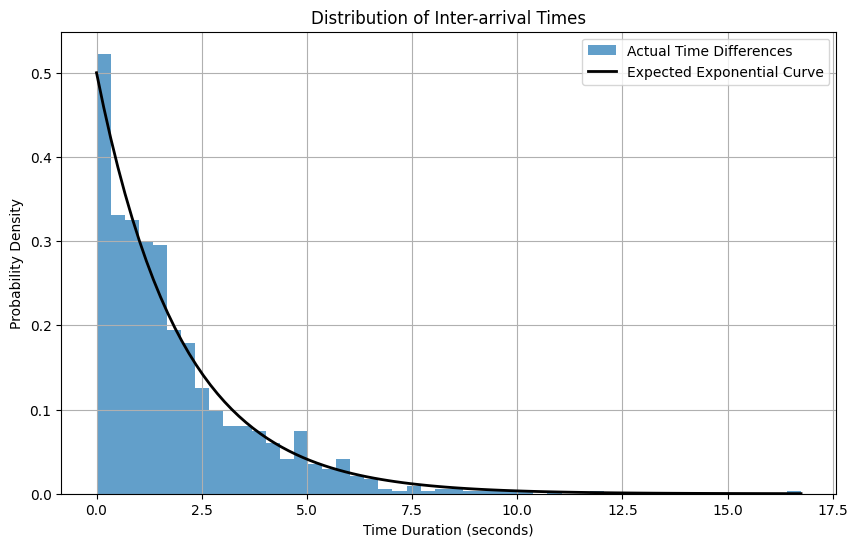


Running Traffic Scenario
Time 0.48: Car-1 reaches the crossing.
Time 0.48: Car-1 proceeds on GREEN.
Time 2.15: Car-1 clears the junction. Time taken: 1.67s.
Time 4.65: Car-2 reaches the crossing.
Time 4.65: Car-2 proceeds on GREEN.
Time 5.46: Car-2 clears the junction. Time taken: 0.81s.
Time 6.14: Car-3 reaches the crossing.
Time 6.14: Car-3 proceeds on GREEN.
Time 6.60: Car-3 clears the junction. Time taken: 0.46s.
Time 6.98: Car-4 reaches the crossing.
Time 6.98: Car-4 proceeds on GREEN.
Time 8.07: Car-4 clears the junction. Time taken: 1.09s.
Time 8.56: Car-5 reaches the crossing.
Time 8.56: Car-5 proceeds on GREEN.
Time 9.49: Car-6 reaches the crossing.
Time 9.49: Car-6 proceeds on GREEN.
Time 10.17: Car-7 reaches the crossing.
Time 10.17: Car-7 proceeds on GREEN.
Time 11.15: Car-5 clears the junction. Time taken: 2.59s.
Time 11.17: Car-6 clears the junction. Time taken: 1.68s.
Time 11.70: Car-8 reaches the crossing.
Time 11.70: Car-8 proceeds on GREEN.
Time 11.80: Car-7 clears t

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import simpy
from collections import defaultdict

# Section 1: Random Variate Production

print("Starting Generator Setup")

# Configuration for LCG
LCG_MULTIPLIER = 1664525
LCG_INCREMENT = 1013904223
LCG_MODULUS = 2**32
STARTING_VAL = 123456789
SAMPLE_COUNT = 1000

def linear_gen(start_val, multiplier, increment, modulus, num_to_make):
    output_array = []
    current_val = start_val
    for _ in range(num_to_make):
        current_val = (multiplier * current_val + increment) % modulus
        output_array.append(current_val / modulus)
    return output_array

uniform_data = linear_gen(STARTING_VAL, LCG_MULTIPLIER, LCG_INCREMENT, LCG_MODULUS, SAMPLE_COUNT)
EXPONENTIAL_RATE = 0.5
time_between_arrivals = [(-np.log(1.0 - r) / EXPONENTIAL_RATE) for r in uniform_data]

print(f"Total uniform numbers produced: {len(uniform_data)}.")
print(f"Initial five uniform values: {[f'{v:.4f}' for v in uniform_data[:5]]}")

print(f"\nTotal exponential arrival times calculated: {len(time_between_arrivals)}.")
print(f"Initial five arrival times (s): {[f'{t:.4f}' for t in time_between_arrivals[:5]]}\n")

# Section 2: Visualization

plt.figure(figsize=(10, 6))
plt.hist(time_between_arrivals, bins=50, density=True, alpha=0.7, label='Actual Time Differences')
time_points = np.linspace(0, max(time_between_arrivals), 100)
density_function = EXPONENTIAL_RATE * np.exp(-EXPONENTIAL_RATE * time_points)
plt.plot(time_points, density_function, 'k-', linewidth=2, label='Expected Exponential Curve')
plt.title('Distribution of Inter-arrival Times')
plt.xlabel('Time Duration (seconds)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

# Section 3: Simulation

print("\nRunning Traffic Scenario")

SIGNAL_GREEN = 30
SIGNAL_RED = 25
SERVICE_AVG = 0.8
SIMULATION_END_TIME = 500

class JunctionSignal:

    def __init__(self, environment):
        self.env = environment
        self.current_color = 'green'
        self.signal_process = environment.process(self.run_cycle())

    def run_cycle(self):
        while True:
            self.current_color = 'green'
            yield self.env.timeout(SIGNAL_GREEN)

            self.current_color = 'red'
            yield self.env.timeout(SIGNAL_RED)

def vehicle_activity(env, vehicle_id, road_access, traffic_light_control):
    start_time = env.now
    print(f'Time {env.now:.2f}: {vehicle_id} reaches the crossing.')
    if traffic_light_control.current_color == 'red':
        print(f'Time {env.now:.2f}: {vehicle_id} stops for the RED light.')
        while traffic_light_control.current_color == 'red':
            yield env.timeout(1)

    print(f'Time {env.now:.2f}: {vehicle_id} proceeds on GREEN.')
    with road_access.request() as access_request:
        yield access_request
        crossing_duration = np.random.exponential(1.0 / SERVICE_AVG)
        yield env.timeout(crossing_duration)

        finish_delay = env.now - start_time
        print(f'Time {env.now:.2f}: {vehicle_id} clears the junction. Time taken: {finish_delay:.2f}s.')

def vehicle_spawner(env, road_access, traffic_light_control, delay_list):
    for index, arrival_delay in enumerate(delay_list):
        yield env.timeout(arrival_delay)
        env.process(vehicle_activity(env, f'Car-{index+1}', road_access, traffic_light_control))

sim_environment = simpy.Environment()
road_resource = simpy.Resource(sim_environment, capacity=1)
signal_controller = JunctionSignal(sim_environment)
sim_environment.process(vehicle_spawner(sim_environment, road_resource, signal_controller, time_between_arrivals))
sim_environment.run(until=SIMULATION_END_TIME)

print("\nSection 4: Statistical Checks")

bin_count_val = 10
observed_counts, _ = np.histogram(uniform_data, bins=bin_count_val, range=(0,1))
expected_counts = [SAMPLE_COUNT / bin_count_val] * bin_count_val
chi_squared_test, chi_squared_p = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Chi-Square Score: {chi_squared_test:.4f}")
print(f"P-Value from Chi-Square: {chi_squared_p:.4f}")
if chi_squared_p > 0.05:
    print("Decision (0.05 level): We find no evidence to reject uniformity.")
else:
    print("Decision (0.05 level): We must reject uniformity.")

ks_test_score, ks_test_p = stats.kstest(uniform_data, 'uniform')

print(f"Kolmogorov-Smirnov Score: {ks_test_score:.4f}")
print(f"P-Value from K-S: {ks_test_p:.4f}")
if ks_test_p > 0.05:
    print("Decision (0.05 level): Data appears consistent with uniform distribution.")
else:
    print("Decision (0.05 level): Data is likely not uniform.")
def runs_analysis(input_data):
    sign_array = np.sign(np.diff(input_data))
    run_count = np.sum(sign_array[:-1] != sign_array[1:]) + 1

    data_length = len(input_data)
    expected_R = (2 * data_length - 1) / 3
    var_R = (16 * data_length - 29) / 90
    z_score = (run_count - expected_R) / np.sqrt(var_R)
    p_val = 2 * (1 - stats.norm.cdf(abs(z_score)))
    return run_count, z_score, p_val

run_tally, z_stat_R, p_val_R = runs_analysis(uniform_data)

print("\nSection 5: Randomness Check")

print(f"Total Runs Counted: {run_tally}")
print(f"Z-Score for Runs: {z_stat_R:.4f}")
print(f"P-Value for Runs: {p_val_R:.4f}")
if p_val_R > 0.05:
    print("Decision (0.05 level): The sequence seems random.")
else:
    print("Decision (0.05 level): The sequence does not seem random.")

In [ ]:
pip install simpy